## DEPENDENCIES

In [1]:
# COMMON
import numpy as np
import sys
import os
import random
import time
import datetime
import pandas as pd
import matplotlib.pyplot as plt

# Triggering Mechanism
import triggering as trig

# Signal Processing
from scipy import signal  # for signal processing
from scipy.signal import hilbert  # for signal processing
import prenn # for deep learning

# AI
import keras
import tensorflow as tf # for deep learning

# 检查版本信息
print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

# 使用TensorFlow的Keras API
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import TensorBoard # for visualization

import onnxruntime as ort # for onnx runtime

# Visualization
# %matplotlib qt5
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation

TensorFlow version: 2.18.0
Keras version: 3.8.0


## CLOSED-LOOP CONTROL COMPONENTS SETUP

### ENVIRONMENT

IN NATURE - THE SYNTHESIZED RESPONSE DATA - DIFFERENT FROM STAGE II

In [2]:
# Corrected Paths
AVPath = r'../01-PRE-DEPLOYMENT/DATA/VAL_RES/VAL_DATA_AV.npy' 
EQPath = r'../01-PRE-DEPLOYMENT/DATA/VAL_RES/VAL_DATA_EQ.npy'
IPPath = r'../01-PRE-DEPLOYMENT/DATA/VAL_RES/VAL_DATA_IP.npy'
SWPath = r'../01-PRE-DEPLOYMENT/DATA/VAL_RES/VAL_DATA_SW.npy'

# Load Data
RESPONSE_AV = np.load(AVPath)
RESPONSE_EQ = np.load(EQPath)
RESPONSE_IP = np.load(IPPath)
RESPONSE_SW = np.load(SWPath)

## only use part of the data
raw_len_av = RESPONSE_AV.shape[0]
raw_len_eq = RESPONSE_EQ.shape[0]
raw_len_ip = RESPONSE_IP.shape[0]
raw_len_sw = RESPONSE_SW.shape[0]

# this is to simulate the imbalanced data - ensure the same ratio within STAGE III
ratio_aw = 0.6
ratio_eq = 1
ratio_ip = 1
ratio_sw = 1

uselen_aw = int(raw_len_av * ratio_aw)
uselen_eq = int(raw_len_eq * ratio_eq)  
uselen_ip = int(raw_len_ip * ratio_ip)
uselen_sw = int(raw_len_sw * ratio_sw)

# randomly pick uselen_aw samples from RESPONSE_XX, no repeat
idx_aw = random.sample(range(raw_len_av), uselen_aw)
idx_eq = random.sample(range(raw_len_eq), uselen_eq)
idx_ip = random.sample(range(raw_len_ip), uselen_ip)
idx_sw = random.sample(range(raw_len_sw), uselen_sw)

RESPONSE_AV = RESPONSE_AV[idx_aw]
RESPONSE_EQ = RESPONSE_EQ[idx_eq]
RESPONSE_IP = RESPONSE_IP[idx_ip]
RESPONSE_SW = RESPONSE_SW[idx_sw]

## Check Data Info
print(type(RESPONSE_AV))
print('RESPONSE_AV Shape:', RESPONSE_AV.shape)
print(type(RESPONSE_EQ))
print('RESPONSE_EQ Shape:', RESPONSE_EQ.shape)
print(type(RESPONSE_IP))
print('RESPONSE_IP Shape:', RESPONSE_IP.shape)
print(type(RESPONSE_SW))
print('RESPONSE_SW Shape:', RESPONSE_SW.shape)

num_type = 4

signal_length = RESPONSE_AV.shape[1]

LenTS = signal_length

# ratio of non-interested data to interested data
ratio_ni = RESPONSE_AV.shape[0] / (RESPONSE_EQ.shape[0] + RESPONSE_IP.shape[0] + RESPONSE_SW.shape[0])

print('Ratio of Non-Interested Data to Interested Data:', ratio_ni)

## Stack Data
RESPONSE = np.vstack((RESPONSE_AV, RESPONSE_EQ, RESPONSE_IP, RESPONSE_SW))

## Total Number of Samples
NumSample = RESPONSE.shape[0]
print('Total Number of Samples:', NumSample) 

<class 'numpy.ndarray'>
RESPONSE_AV Shape: (150, 6000)
<class 'numpy.ndarray'>
RESPONSE_EQ Shape: (50, 6000)
<class 'numpy.ndarray'>
RESPONSE_IP Shape: (50, 6000)
<class 'numpy.ndarray'>
RESPONSE_SW Shape: (50, 6000)
Ratio of Non-Interested Data to Interested Data: 1.0
Total Number of Samples: 300


In [3]:
NUM_AV = RESPONSE_AV.shape[0]
NUM_EQ = RESPONSE_EQ.shape[0]
NUM_IP = RESPONSE_IP.shape[0]
NUM_SW = RESPONSE_SW.shape[0]

#print
print('Number of AV:', NUM_AV)
print('Number of EQ:', NUM_EQ)
print('Number of IP:', NUM_IP)
print('Number of SW:', NUM_SW)

Number of AV: 150
Number of EQ: 50
Number of IP: 50
Number of SW: 50


### SYSTEM
IN NATURE - THE TRIGGERING MECHANISM

In [4]:
# embodied in the triggering.py

In [5]:
# determine the search space by check the maximum and minimum of the data - ambient vibration
max_noise = np.max(abs(RESPONSE_AV))
min_noise = np.min(abs(RESPONSE_AV))
print('Maximum of AV:', max_noise)
print('Minimum of AV:', min_noise)

# determine the lower and upper bound of the search space
ub_factor = 2
lb_factor = 0.01

Maximum of AV: 0.01547498134477587
Minimum of AV: 5.471121479784513e-07


In [6]:
# configuration

## para_a stands for the triggering threshold amplitude (continuous)
para_a_lb = lb_factor*(max_noise + min_noise)/2
para_a_ub = ub_factor*(max_noise + min_noise)/2

print('Lower Bound of para_a:', para_a_lb)
print('Upper Bound of para_a:', para_a_ub)

## para_b stands for the triggering threshold duration (discrete integer)
para_b_lb = 2
para_b_ub = 10

print('Lower Bound of para_b:', para_b_lb)
print('Upper Bound of para_b:', para_b_ub)

Lower Bound of para_a: 7.737764228461925e-05
Upper Bound of para_a: 0.015475528456923848
Lower Bound of para_b: 2
Upper Bound of para_b: 10


In [7]:
# test
test_data = RESPONSE_AV[0]

para_a = 0.5
para_b = 2

trig_flg = trig.activation(test_data, para_a, para_b)
print(trig_flg[0]) # the first element stands for the triggering flag, and the second element stands for the triggering time

0


### ESTIMATOR
IN NATURE - TRIGGERING MECHANISM & GROUND TRUTH

In [8]:
beta = 3 # beta value to balance the precision and recall

In [9]:
# USED PARAMETER of the Dataset

# nn_in_len = 128 # nn input length can be automatically calculated from the model input size
dt = 0.01  # time step, change according to the dataset
nperseg = 128 # number of points for each segment in spectrogram

#### Classifier - CNN Model

In [10]:
# CNN Classifier Model - 尝试多种方法加载原始模型
print("尝试加载原始CNN模型...")

# 尝试不同的模型文件和方法
model_paths = [
    r'../01-PRE-DEPLOYMENT/03-NN-TRAINING-CNN/cnn_model.keras',
    r'../01-PRE-DEPLOYMENT/03-NN-TRAINING-CNN/best_model.keras'
]

CNN_Model = None
loaded_successfully = False

for model_path in model_paths:
    if os.path.exists(model_path):
        print(f"尝试加载模型: {model_path}")
        
        # 方法1: 使用tf.keras.models.load_model with custom_objects
        try:
            CNN_Model = tf.keras.models.load_model(model_path, compile=False)
            print(f"✅ 成功使用 tf.keras.models.load_model (compile=False) 加载: {model_path}")
            loaded_successfully = True
            break
        except Exception as e1:
            print(f"❌ tf.keras.models.load_model (compile=False) 失败: {e1}")
        
        # 方法2: 使用tf.keras.models.load_model with safe_mode=False
        try:
            CNN_Model = tf.keras.models.load_model(model_path, safe_mode=False)
            print(f"✅ 成功使用 tf.keras.models.load_model (safe_mode=False) 加载: {model_path}")
            loaded_successfully = True
            break
        except Exception as e2:
            print(f"❌ tf.keras.models.load_model (safe_mode=False) 失败: {e2}")
        
        # 方法3: 使用keras.saving.load_model with custom_objects
        try:
            import keras
            CNN_Model = keras.saving.load_model(model_path, custom_objects=None)
            print(f"✅ 成功使用 keras.saving.load_model 加载: {model_path}")
            loaded_successfully = True
            break
        except Exception as e3:
            print(f"❌ keras.saving.load_model 失败: {e3}")
        
        # 方法4: 尝试使用pickle加载
        try:
            import pickle
            with open(model_path, 'rb') as f:
                CNN_Model = pickle.load(f)
            print(f"✅ 成功使用 pickle 加载: {model_path}")
            loaded_successfully = True
            break
        except Exception as e4:
            print(f"❌ pickle 加载失败: {e4}")

if not loaded_successfully:
    print("\n⚠️ 所有加载方法都失败了！")
    print("尝试使用ONNX运行时加载...")
    
    # 方法5: 尝试ONNX运行时
    try:
        import onnxruntime as ort
        # 假设有ONNX格式的模型
        onnx_path = model_paths[0].replace('.keras', '.onnx')
        if os.path.exists(onnx_path):
            session = ort.InferenceSession(onnx_path)
            print(f"✅ 成功使用 ONNX 运行时加载: {onnx_path}")
            # 创建一个包装器来模拟Keras模型接口
            class ONNXModelWrapper:
                def __init__(self, session):
                    self.session = session
                    self.input_shape = (None, 128, 1)  # 根据错误信息推断
                
                def predict(self, x, verbose=0):
                    # 转换输入格式
                    input_name = self.session.get_inputs()[0].name
                    output_name = self.session.get_outputs()[0].name
                    result = self.session.run([output_name], {input_name: x.numpy() if hasattr(x, 'numpy') else x})
                    return result[0]
                
                def summary(self):
                    print("ONNX Model loaded successfully")
            
            CNN_Model = ONNXModelWrapper(session)
            loaded_successfully = True
        else:
            print("❌ 未找到ONNX格式的模型文件")
    except Exception as e5:
        print(f"❌ ONNX 加载失败: {e5}")

if not loaded_successfully:
    print("\n🚨 无法加载任何原始模型！")
    print("将使用随机权重的模型（结果可能不准确）")
    
    # 作为最后手段，创建随机权重的模型
    def create_cnn_model():
        model = tf.keras.Sequential([
            tf.keras.layers.InputLayer(input_shape=(128, 1), name='input_layer'),
            tf.keras.layers.Conv1D(filters=4, kernel_size=3, strides=1, padding='same', 
                                  activation='linear', use_bias=True, name='conv1d'),
            tf.keras.layers.BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001, 
                                              center=True, scale=True, name='batch_normalization'),
            tf.keras.layers.ReLU(name='re_lu'),
            tf.keras.layers.GlobalAveragePooling1D(data_format='channels_last', 
                                                  keepdims=False, name='global_average_pooling1d'),
            tf.keras.layers.Dense(units=4, activation='softmax', use_bias=True, name='dense')
        ])
        
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss='sparse_categorical_crossentropy',
            metrics=['sparse_categorical_accuracy']
        )
        return model
    
    CNN_Model = create_cnn_model()
    print("⚠️ 使用随机权重的模型（结果可能不准确）")

if CNN_Model:
    print(f"\n✅ 模型加载完成！")
    if hasattr(CNN_Model, 'summary'):
        CNN_Model.summary()
    else:
        print("模型类型:", type(CNN_Model))

尝试加载原始CNN模型...
尝试加载模型: ../01-PRE-DEPLOYMENT/03-NN-TRAINING-CNN/cnn_model.keras
✅ 成功使用 tf.keras.models.load_model (compile=False) 加载: ../01-PRE-DEPLOYMENT/03-NN-TRAINING-CNN/cnn_model.keras

✅ 模型加载完成！


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 128, 4)         │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 4)         │            16 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 4)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 4)              │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │            20 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52 (208.00 B)

 Trainable params: 44 (176.00 B)

 Non-trainable params: 8 (32.00 B)

Predictor - DNN Model

In [11]:
# DNN Predictor Models - 尝试多种方法加载原始模型
print("尝试加载原始DNN模型...")

# 尝试不同的模型文件和方法
recall_model_paths = [
    r'../01-PRE-DEPLOYMENT/04-NN-TRAINING-DNN/recall_est.keras'
]

precision_model_paths = [
    r'../01-PRE-DEPLOYMENT/04-NN-TRAINING-DNN/precision_est.keras'
]

def load_model_with_multiple_methods(model_paths, model_name):
    model = None
    loaded_successfully = False
    
    for model_path in model_paths:
        if os.path.exists(model_path):
            print(f"尝试加载{model_name}模型: {model_path}")
            
            # 方法1: 使用tf.keras.models.load_model with compile=False
            try:
                model = tf.keras.models.load_model(model_path, compile=False)
                print(f"✅ 成功使用 tf.keras.models.load_model (compile=False) 加载{model_name}: {model_path}")
                loaded_successfully = True
                break
            except Exception as e1:
                print(f"❌ tf.keras.models.load_model (compile=False) 失败: {e1}")
            
            # 方法2: 使用tf.keras.models.load_model with safe_mode=False
            try:
                model = tf.keras.models.load_model(model_path, safe_mode=False)
                print(f"✅ 成功使用 tf.keras.models.load_model (safe_mode=False) 加载{model_name}: {model_path}")
                loaded_successfully = True
                break
            except Exception as e2:
                print(f"❌ tf.keras.models.load_model (safe_mode=False) 失败: {e2}")
            
            # 方法3: 使用keras.saving.load_model
            try:
                import keras
                model = keras.saving.load_model(model_path, custom_objects=None)
                print(f"✅ 成功使用 keras.saving.load_model 加载{model_name}: {model_path}")
                loaded_successfully = True
                break
            except Exception as e3:
                print(f"❌ keras.saving.load_model 失败: {e3}")
    
    if not loaded_successfully:
        print(f"⚠️ 无法加载{model_name}模型，将使用随机权重")
        # 创建随机权重的模型作为后备
        model = tf.keras.Sequential([
            tf.keras.layers.Dense(64, activation='relu', input_shape=(3,)),
            tf.keras.layers.Dropout(0.2),
            tf.keras.layers.Dense(32, activation='relu'),
            tf.keras.layers.Dropout(0.2),
            tf.keras.layers.Dense(1, activation='sigmoid')
        ])
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss='mse',
            metrics=['mae']
        )
    
    return model, loaded_successfully

# 加载Recall模型
Recall_Model, recall_loaded = load_model_with_multiple_methods(recall_model_paths, "Recall")

# 加载Precision模型
Precision_Model, precision_loaded = load_model_with_multiple_methods(precision_model_paths, "Precision")

print(f"\n✅ DNN模型加载完成！")
print(f"Recall模型: {'原始权重' if recall_loaded else '随机权重'}")
print(f"Precision模型: {'原始权重' if precision_loaded else '随机权重'}")

if hasattr(Recall_Model, 'summary'):
    print("\nRecall Model Summary:")
    Recall_Model.summary()

if hasattr(Precision_Model, 'summary'):
    print("\nPrecision Model Summary:")
    Precision_Model.summary()

尝试加载原始DNN模型...
尝试加载Recall模型: ../01-PRE-DEPLOYMENT/04-NN-TRAINING-DNN/recall_est.keras
✅ 成功使用 tf.keras.models.load_model (compile=False) 加载Recall: ../01-PRE-DEPLOYMENT/04-NN-TRAINING-DNN/recall_est.keras
尝试加载Precision模型: ../01-PRE-DEPLOYMENT/04-NN-TRAINING-DNN/precision_est.keras
✅ 成功使用 tf.keras.models.load_model (compile=False) 加载Precision: ../01-PRE-DEPLOYMENT/04-NN-TRAINING-DNN/precision_est.keras

✅ DNN模型加载完成！
Recall模型: 原始权重
Precision模型: 原始权重

Recall Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
# get the input data length
nn_in_len = CNN_Model.input_shape[1]
print('Input Data Length:', nn_in_len)



Input Data Length: 128


Test Data Shape: (1, 6000)


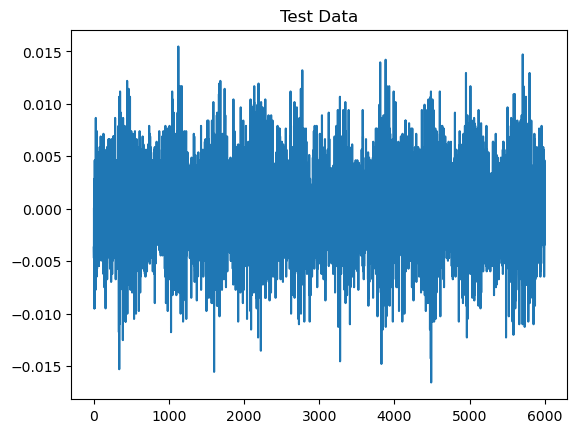

In [13]:
# model test by loading a piece of data from the dataset, and feed intot he prenn function

# index for the random data
idx = np.random.randint(NumSample)

# get the data
test_data = RESPONSE[idx, :].reshape(1, LenTS)

print('Test Data Shape:', test_data.shape)

# plot the test data
plt.figure()
plt.plot(test_data[0, :])
plt.title('Test Data')
plt.show()


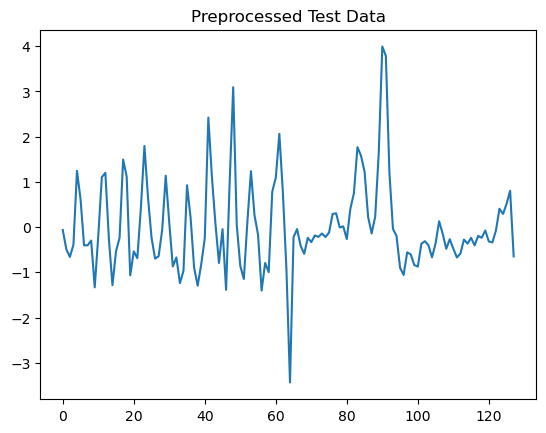

In [14]:
# preprocess
output_length = nn_in_len
test_data = prenn.prenn(test_data, dt, nperseg, output_length)

# print the preprocessed data
plt.figure()
plt.plot(test_data[0, :])
plt.title('Preprocessed Test Data')
plt.show()

In [15]:
test_data = test_data.reshape(1, nn_in_len, 1)

print('Preprocessed Test Data Shape:', test_data.shape)

# test the model
test_result = CNN_Model.predict(test_data)
print('Tensorflow Model Prediction:', test_result)

# parse the result to get the label
result_label = np.argmax(test_result)

print('Tensorflow Model Prediction:', result_label)

Preprocessed Test Data Shape: (1, 128, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Tensorflow Model Prediction: [[9.1945750e-01 1.1951682e-06 4.1350678e-02 3.9190691e-02]]
Tensorflow Model Prediction: 0


In [16]:
# Ex

## BAYESIAN OPTIMIZATION FRAMEWORK

### Helper Functions

In [17]:
# %pip install PyQt5
# %pip install colorama


In [18]:
# # use pop-up window for plots
# %matplotlib qt5 
# from mpl_toolkits.mplot3d import Axes3D
# from matplotlib.animation import FuncAnimation
# # print control
# from colorama import init, Fore, Back, Style

In [19]:
# CONFIGURABLE PARAMETERS

## Hyperparameters
noise_lvl = 0.1
k_alpha = 1
k_lambda = 1

## Process Control
num_init_points = 15
num_iter = 20
tolerance = 1e-3
gap = np.inf

## Acquisition Function - UCB
ucb_beta = 0.5

## Acquisition Function - PI & EI
xi=0.01

## Bonus factor for evaluation
bonus_factor = 1.1

## Grid Search Configuration
num_threshold_points = 170  # 阈值划分点数，可调整

In [20]:
## Grid Search Space
### parameter 1 - a (threshold amplitude)
# 从0到0.01706分等分
lb_a = 0.0
ub_a = 0.01706
num_points_a = num_threshold_points  # 使用配置变量
para_a_values = np.linspace(lb_a, ub_a, num_points_a)
print('Lower Bound of para_a:', lb_a)
print('Upper Bound of para_a:', ub_a)
print('Number of points for para_a:', num_points_a)
print('para_a values:', para_a_values)

### parameter 2 - b (duration)
# 从2到10，共9个整数点
lb_b = 2
ub_b = 10
para_b_values = np.arange(lb_b, ub_b + 1)
print('Lower Bound of para_b:', lb_b)
print('Upper Bound of para_b:', ub_b)
print('Number of points for para_b:', len(para_b_values))
print('para_b values:', para_b_values)

# 计算总的网格搜索点数
total_grid_points = len(para_a_values) * len(para_b_values)
print('Total grid search points:', total_grid_points)

Lower Bound of para_a: 0.0
Upper Bound of para_a: 0.01706
Number of points for para_a: 170
para_a values: [0.         0.00010095 0.00020189 0.00030284 0.00040379 0.00050473
 0.00060568 0.00070663 0.00080757 0.00090852 0.00100947 0.00111041
 0.00121136 0.00131231 0.00141325 0.0015142  0.00161515 0.00171609
 0.00181704 0.00191799 0.00201893 0.00211988 0.00222083 0.00232178
 0.00242272 0.00252367 0.00262462 0.00272556 0.00282651 0.00292746
 0.0030284  0.00312935 0.0032303  0.00333124 0.00343219 0.00353314
 0.00363408 0.00373503 0.00383598 0.00393692 0.00403787 0.00413882
 0.00423976 0.00434071 0.00444166 0.0045426  0.00464355 0.0047445
 0.00484544 0.00494639 0.00504734 0.00514828 0.00524923 0.00535018
 0.00545112 0.00555207 0.00565302 0.00575396 0.00585491 0.00595586
 0.0060568  0.00615775 0.0062587  0.00635964 0.00646059 0.00656154
 0.00666249 0.00676343 0.00686438 0.00696533 0.00706627 0.00716722
 0.00726817 0.00736911 0.00747006 0.00757101 0.00767195 0.0077729
 0.00787385 0.00797479 0.

### The Problem / System to Optimize

Triggering Mechanism： Triggering Parameters In; Evaluation Index Out

In [21]:
# THE OBJECTIVE FUNCTION (for manual setup evaluation)
def objective_function_manual(para_a, para_b):

    """ Function with unknown internals we wish to maximize.

    This function defines the process to evaluate how good the parameters are for the triggering sensing mechanism.

    INPUT:
    - para_a: the threshold for the activation, positive real number
    - para_b: activate_duration: the duration for the activation, positive integer >= 2 (as we know 1 is not error-prone in practice)

    OUTPUT:
    - evaluation value: F-beta score
    
    HYPERPARAMETERS:
    - beta: the value to balance the precision and recall to calculate F-beta score
    
    """
    
    # assistive variables
    TP = 0
    FP = 0
    FN = 0
    TN = 0
    
    # go through the dataset
    for i in range(NumSample):
    # for i in range(10):  
        # trigger flag
        flg_trigger = 0
        
        # ground truth flag
        flg_class = 0
        flg_interst = 0
        
        # get the response data
        signal = RESPONSE[i, :].reshape(1, -1)
        
        # get the triggering mechanism
        flg_trigger, trig_pos = trig.activation(signal, para_a, para_b)
        
        # print('Trigger Flag:', flg_trigger)
        
        # get the ground truth
        if i < NUM_AV:
            flg_interst = 0
            flag_class = 0
        elif i < NUM_AV + NUM_EQ:
            flg_interst = 1
            flag_class = 1
        elif i < NUM_AV + NUM_EQ + NUM_IP:
            flg_interst = 1
            flag_class = 2
        else:
            flg_interst = 1
            flag_class = 3

        # get the confusion matrix - as the number of interested data is assumed to be small, we need to consider the ratio - only two classes - interested and non-interested
        if flg_trigger == 1 and flg_interst == 1:
            TP += 1*ratio_ni
        elif flg_trigger == 1 and flg_interst == 0:
            FP += 1
        elif flg_trigger == 0 and flg_interst == 1:
            FN += 1*ratio_ni
        elif flg_trigger == 0 and flg_interst == 0:
            TN += 1
        else:
            print('Error in Confusion Matrix Calculation')
            
    # demoninator
    denominator = ((1 + beta**2) * TP + beta**2 * FN + FP)
    if denominator == 0:
        F_beta = 0
        return 0
    
    F_beta = (1 + beta**2) * TP / ((1 + beta**2) * TP + beta**2 * FN + FP)
    
    # if F_beta is NaN, return 0
    if np.isnan(F_beta):
        F_beta = 0
        return 0
    
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    
    if precision > 0.9 and recall > 0.9:
        F_beta = F_beta * bonus_factor
    
    # print TP, FP, FN, TN as integer, Precision, Recall, F-beta as float number with 4 decimal places
    print(f'para_a / para_b / TP / FP / FN / TN / Precision / Recall / F-beta: {para_a} {para_b} {int(TP)} {int(FP)} {int(FN)} {int(TN)} {precision:.4f} {recall:.4f} {F_beta:.4f}')


    return F_beta, TP, FP, FN, TN, precision, recall


In [22]:
# TEST / MANUAL CHECK

para_a = 0.00648
para_b = 2

manual_setup = objective_function_manual(para_a, para_b)

manual_f_beta = manual_setup[0]

manual_precision = manual_setup[-2]

manual_recall = manual_setup[-1]

print('Manual F-beta:', manual_f_beta)

print('Manual Precision:', manual_precision)

print('Manual Recall:', manual_recall)

para_a / para_b / TP / FP / FN / TN / Precision / Recall / F-beta: 0.00648 2 150 150 0 0 0.5000 1.0000 0.9091
Manual F-beta: 0.9090909090909091
Manual Precision: 0.5
Manual Recall: 1.0


In [23]:
# THE OBJECTIVE FUNCTION (for onboard fine tuning)
def objective_function(para_a, para_b):

    """ Function with unknown internals we wish to maximize.

    This function defines the process to evaluate how good the parameters are for the triggering sensing mechanism.

    INPUT:
    - para_a: the threshold for the activation, positive real number
    - para_b: activate_duration: the duration for the activation, positive integer >= 2 (as we know 1 is not error-prone in practice)

    OUTPUT:
    - evaluation value: F-beta score
    
    HYPERPARAMETERS:
    - beta: the value to balance the precision and recall to calculate F-beta score
    
    """
    
    # assistive variables
    TP = 0
    FP = 0
    FN = 0
    TN = 0
    
    # go through the dataset
    for i in range(NumSample):
    # for i in range(10):  
        # trigger flag
        flg_trigger = 0
        
        # ground truth flag
        class_1h = np.zeros((1, num_type))
        flg_class = 0
        flg_interst = 0
        
        # get the response data
        signal = RESPONSE[i, :].reshape(1, LenTS)
        
        # get the triggering mechanism
        flg_trigger, trig_pos = trig.activation(signal, para_a, para_b)
        
        # print('Trigger Flag:', flg_trigger)
        
        # preprocess the signal for the CNN model to get the ground truth
        signal = prenn.prenn(signal, dt, nperseg, nn_in_len)
        
        signal = signal.reshape(1, nn_in_len, 1)

        # get the ground truth
        class_1h = CNN_Model.predict(signal, verbose=0)
        flag_class = np.argmax(class_1h)
        
        # get the ground truth
        if flag_class > 0:
            flg_interst = 1

        # get the confusion matrix - as the number of interested data is assumed to be small, we need to consider the ratio - only two classes - interested and non-interested
        if flg_trigger == 1 and flg_interst == 1:
            TP += 1
        elif flg_trigger == 1 and flg_interst == 0:
            FP += 1
        elif flg_trigger == 0 and flg_interst == 1:
            FN = -1 # no use, recall will be calculated in other way
        elif flg_trigger == 0 and flg_interst == 0:
            TN = -1 # no use, recall will be calculated in other way
        else:
            print('Error in Confusion Matrix Calculation')
    
    # recall = Precision_Model
    std_av = np.std(RESPONSE_AV[0, :])
    recall_input = np.array([std_av, para_a, para_b]).reshape(1, 3)
    recall = Recall_Model.predict(recall_input)
    recall = float(recall)
    
    # if recall > 1:
    #     recall = 1
    # if recall < 0:
    #     recall = 0
    
    # calculate precision
    precision = TP / (TP + FP)
            
    # calculate the F-beta score
    denominator = (beta**2) * precision + recall 
    if denominator == 0:
        F_beta = 0
    else:
        F_beta = (1 + beta**2) * precision * recall / denominator
    
    # if F_beta is NaN, return 0
    if np.isnan(F_beta):
        F_beta = 0
        return 0
    
    if precision > 0.9 and recall > 0.9:
        F_beta = F_beta * bonus_factor

    
    
    # print TP, FP, FN, TN as integer, Precision, Recall, F-beta as float number with 4 decimal places
    # print('para_a / para_b /TP / FP / FN / TN / Precision / Recall / F-beta:', para_a, para_b, TP, FP, FN, TN, f'{precision:.4f}', f'{recall:.4f}', f'{F_beta:.4f}')  
    # print('para_a / para_b ', para_a, para_b)  
    # print('TP / FP / FN / TN / Precision / Recall / F-beta:', TP, FP, FN, TN)  
    # print('Precision / Recall / F-beta:', f'{precision:.4f}', f'{recall:.4f}', f'{F_beta:.4f}')  
    print(f'para_a / para_b / TP / FP / FN / TN / Precision / Recall / F-beta: {para_a} {para_b} {int(TP)} {int(FP)} {int(FN)} {int(TN)} {precision:.4f} {recall:.4f} {F_beta:.4f}')

    return F_beta, TP, FP, FN, TN, precision, recall


### The Optimization Process

In [24]:
# GRID SEARCH OPTIMIZATION
# 初始化结果存储
grid_results = []
best_f_beta = -np.inf
best_params = None
best_index = 0

print(f'Starting Grid Search with {total_grid_points} total combinations...')
print('=' * 60)

# 遍历所有参数组合
iteration = 0
for i, para_a in enumerate(para_a_values):
    for j, para_b in enumerate(para_b_values):
        iteration += 1
        
        # 评估目标函数
        tmp = objective_function(para_a, para_b)
        f_eval = tmp[0]
        
        # 存储结果
        result = {
            'iteration': iteration,
            'para_a': para_a,
            'para_b': para_b,
            'f_beta': f_eval,
            'TP': tmp[1],
            'FP': tmp[2], 
            'FN': tmp[3],
            'TN': tmp[4],
            'precision': tmp[5],
            'recall': tmp[6]
        }
        grid_results.append(result)
        
        # 更新最佳值
        if f_eval > best_f_beta:
            best_f_beta = f_eval
            best_params = (para_a, para_b)
            best_index = iteration
            print(f'Grid Search {iteration}/{total_grid_points}: New Best F-beta = {best_f_beta:.4f} at para_a={para_a:.6f}, para_b={para_b}')
        else:
            print(f'Grid Search {iteration}/{total_grid_points}: F-beta = {f_eval:.4f} at para_a={para_a:.6f}, para_b={para_b}')

print('=' * 60)
print(f'Grid Search Completed!')
print(f'Best F-beta: {best_f_beta:.4f}')
print(f'Best Parameters: para_a={best_params[0]:.6f}, para_b={best_params[1]}')
print(f'Best Index: {best_index}')
    

Starting Grid Search with 1530 total combinations...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
para_a / para_b / TP / FP / FN / TN / Precision / Recall / F-beta: 0.0 2 97 203 0 0 0.3233 0.9924 0.8222
Grid Search 1/1530: New Best F-beta = 0.8222 at para_a=0.000000, para_b=2


C:\Users\cswof\AppData\Local\Temp\ipykernel_39548\1738947824.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  recall = float(recall)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
para_a / para_b / TP / FP / FN / TN / Precision / Recall / F-beta: 0.0 3 97 203 0 0 0.3233 0.9907 0.8212
Grid Search 2/1530: F-beta = 0.8212 at para_a=0.000000, para_b=3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
para_a / para_b / TP / FP / FN / TN / Precision / Recall / F-beta: 0.0 4 97 203 0 0 0.3233 0.9831 0.8165
Grid Search 3/1530: F-beta = 0.8165 at para_a=0.000000, para_b=4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
para_a / para_b / TP / FP / FN / TN / Precision / Recall / F-beta: 0.0 5 97 203 0 0 0.3233 0.9721 0.8096
Grid Search 4/1530: F-beta = 0.8096 at para_a=0.000000, para_b=5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
para_a / para_b / TP / FP / FN / TN / Precision / Recall / F-beta: 0.0 6 97 203 0 0 0.3233 0.9611 0.8027
Grid Search 5/1530: F-beta = 0.8027 at para_a=0.000000, para_b=6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
para_a / para_b / TP / FP / FN / TN / Precision / Recall / F-beta: 0.0 7 97 203 0 0 0.3233 0.9501 0.7958
Grid Search 6/1530: F-bet

In [25]:
# 保存网格搜索结果
# 保存配置参数
grid_config = np.array([lb_a, ub_a, lb_b, ub_b, num_points_a, len(para_b_values), total_grid_points])
np.save('grid_config.npy', grid_config)

# 保存详细的网格搜索结果为CSV格式
import pandas as pd
grid_df = pd.DataFrame(grid_results)
grid_df.to_csv('grid_search_results.csv', index=False)
print('Grid search results saved to grid_search_results.csv')

# 保存最佳结果摘要
best_summary = {
    'best_f_beta': best_f_beta,
    'best_para_a': best_params[0],
    'best_para_b': best_params[1],
    'best_index': best_index,
    'total_combinations': total_grid_points
}
np.save('best_grid_result.npy', best_summary)
print('Best result summary saved to best_grid_result.npy')

# 打印结果摘要
print('\n' + '='*60)
print('GRID SEARCH RESULTS SUMMARY')
print('='*60)
print(f'Total combinations evaluated: {total_grid_points}')
print(f'Best F-beta score: {best_f_beta:.6f}')
print(f'Best para_a (threshold): {best_params[0]:.6f}')
print(f'Best para_b (duration): {best_params[1]}')
print(f'Best combination index: {best_index}')
print('='*60)


Grid search results saved to grid_search_results.csv
Best result summary saved to best_grid_result.npy

GRID SEARCH RESULTS SUMMARY
Total combinations evaluated: 1530
Best F-beta score: 1.028558
Best para_a (threshold): 0.012013
Best para_b (duration): 3
Best combination index: 1073


GRID SEARCH ANALYSIS
Total evaluations: 1530
F-beta score range: 0.7691 - 1.0286
Mean F-beta score: 0.8950
Std F-beta score: 0.0715

Top 5 Results:
  para_a  para_b   f_beta  precision   recall
0.012013       3 1.028558   0.905660 0.938437
0.012114       3 1.027994   0.904762 0.937970
0.012215       3 1.027534   0.904762 0.937503
0.012316       3 1.027075   0.904762 0.937035
0.010297       4 1.026658   0.915094 0.935396


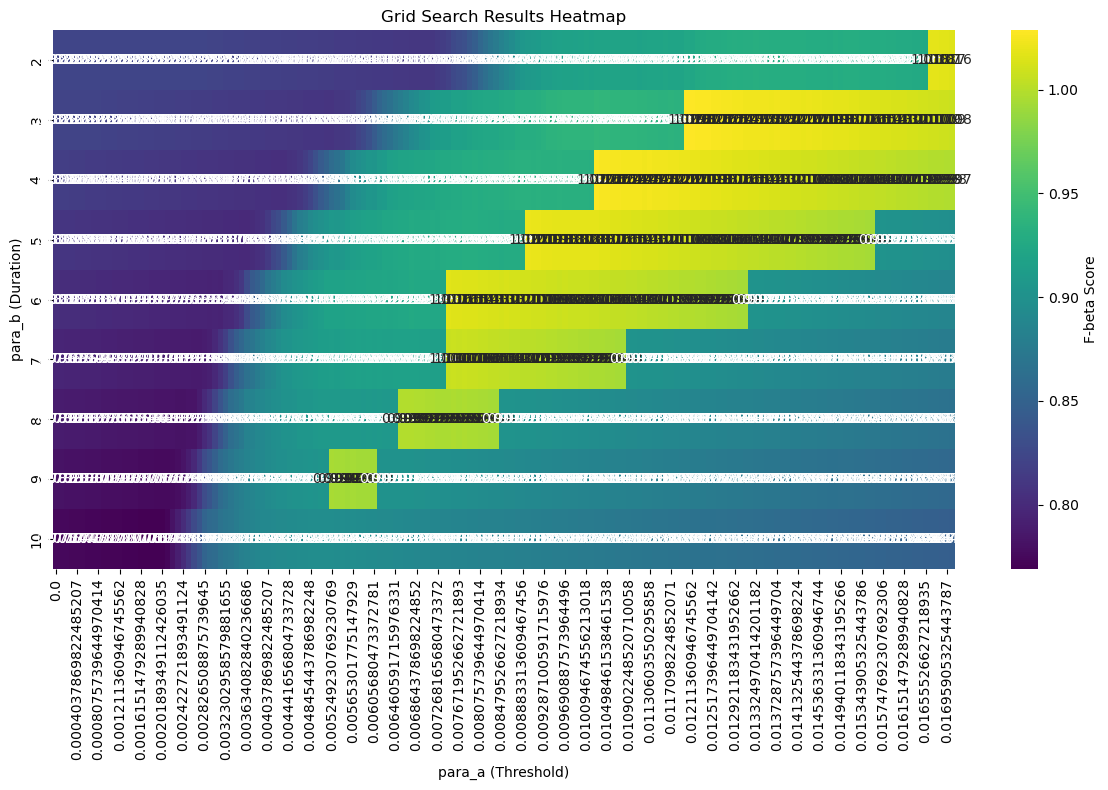

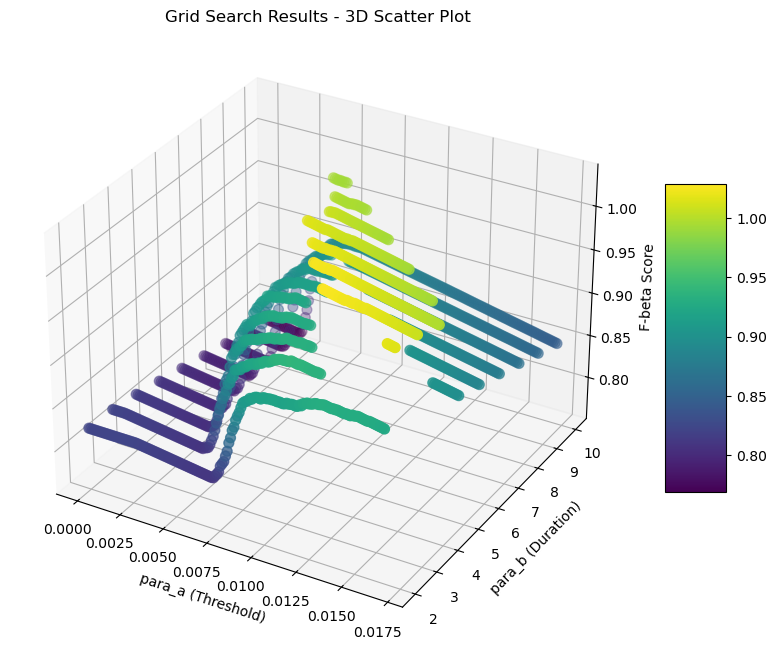


Visualization plots saved as 'grid_search_heatmap.png' and 'grid_search_3d.png'


In [26]:
# 网格搜索结果分析和可视化
print("GRID SEARCH ANALYSIS")
print("="*50)

# 基本统计信息
print(f"Total evaluations: {len(grid_df)}")
print(f"F-beta score range: {grid_df['f_beta'].min():.4f} - {grid_df['f_beta'].max():.4f}")
print(f"Mean F-beta score: {grid_df['f_beta'].mean():.4f}")
print(f"Std F-beta score: {grid_df['f_beta'].std():.4f}")

# 前5个最佳结果
print("\nTop 5 Results:")
top_5 = grid_df.nlargest(5, 'f_beta')[['para_a', 'para_b', 'f_beta', 'precision', 'recall']]
print(top_5.to_string(index=False, float_format='%.6f'))

# 创建热力图显示参数组合的F-beta分数
import matplotlib.pyplot as plt
import seaborn as sns

# 重塑数据为热力图格式
heatmap_data = grid_df.pivot(index='para_b', columns='para_a', values='f_beta')

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='viridis', 
            cbar_kws={'label': 'F-beta Score'})
plt.title('Grid Search Results Heatmap')
plt.xlabel('para_a (Threshold)')
plt.ylabel('para_b (Duration)')
plt.tight_layout()
plt.savefig('grid_search_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 创建3D散点图
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(grid_df['para_a'], grid_df['para_b'], grid_df['f_beta'], 
                    c=grid_df['f_beta'], cmap='viridis', s=50)
ax.set_xlabel('para_a (Threshold)')
ax.set_ylabel('para_b (Duration)')
ax.set_zlabel('F-beta Score')
plt.colorbar(scatter, ax=ax, shrink=0.5, aspect=5)
plt.title('Grid Search Results - 3D Scatter Plot')
plt.savefig('grid_search_3d.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization plots saved as 'grid_search_heatmap.png' and 'grid_search_3d.png'")
